In [1]:
# CatBoost Modelling for HDB Resale Price Nowcasting
# Goal:
# 1. Train a CatBoost model to predict nominal resale prices
# 2. Evaluate predictive performance
# 3. Construct prediction intervals
# 4. Save the trained model for downstream app/API use

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from catboost import CatBoostRegressor
import joblib

In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\Jing Xuan\Desktop\Y3S2\DSE3101\DSE3101 Group Project\hdb_with_amenities_macro.csv")

print(df.shape)
df.head()

(157821, 37)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,dist_nearest_primary_m,primary_schools_1km,dist_nearest_park_m,parks_1km,dist_nearest_sportsg_m,nearest_sportsg_name,dist_nearest_mall_m,nearest_mall_name,dist_nearest_healthcare_m,nearest_healthcare_name
0,2020-01-01,ANG MO KIO,3 ROOM,208,ANG MO KIO AVE 1,04 TO 06,73.0,New Generation,1976,55 years 07 months,...,550.8,ANG MO KIO PRIMARY SCHOOL|TECK GHEE PRIMARY SC...,701.6,MAYFLOWER CRESCENT PG|BISHAN-ANG MO KIO PARK (...,275.0,ActiveSG Gym@Ang Mo Kio Community Centre,767.5,Ang Mo Kio Hub,1040.9,Ang Mo Kio Polyclinic
1,2020-01-01,ANG MO KIO,3 ROOM,307C,ANG MO KIO AVE 1,19 TO 21,70.0,Model A,2012,91 years 08 months,...,649.3,ANG MO KIO PRIMARY SCHOOL|TECK GHEE PRIMARY SC...,695.0,ANG MO KIO TOWN GARDEN EAST|BISHAN-ANG MO KIO ...,520.0,ActiveSG Gym@Ang Mo Kio Community Centre,557.5,Ang Mo Kio Hub,976.1,Ang Mo Kio Polyclinic
2,2020-01-01,ANG MO KIO,3 ROOM,319,ANG MO KIO AVE 1,01 TO 03,73.0,New Generation,1977,56 years 04 months,...,408.0,ANG MO KIO PRIMARY SCHOOL|JING SHAN PRIMARY SC...,536.5,ANG MO KIO TOWN GARDEN EAST|BISHAN-ANG MO KIO ...,324.2,Ang Mo Kio Swimming Complex,493.6,Ang Mo Kio Hub,1041.9,Ang Mo Kio Polyclinic
3,2020-01-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,New Generation,1976,55 years 03 months,...,405.2,ANG MO KIO PRIMARY SCHOOL,577.1,MAYFLOWER CRESCENT PG|BISHAN-ANG MO KIO PARK (...,116.9,ActiveSG Gym@Ang Mo Kio Community Centre,807.7,Broadway Plaza,1015.9,Ang Mo Kio Polyclinic
4,2020-01-01,ANG MO KIO,3 ROOM,556,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,1980,59 years 01 month,...,651.7,JING SHAN PRIMARY SCHOOL,831.9,ANG MO KIO TOWN GARDEN EAST|TAVISTOCK AVE PK|H...,1313.4,Ang Mo Kio Swimming Complex,1071.4,Ang Mo Kio Hub,1352.4,Ang Mo Kio Polyclinic


In [4]:
# Inspect columns and missingness
print(df.columns.tolist())
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))

['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'quarter', 'rpi', 'resale_price_real', 'sora_3m', 'inflation_yoy', 'real_interest_rate', 'sora_3m_lag1', 'real_interest_rate_lag1', 'lat', 'lon', 'nearest_train_line', 'nearest_train_dist_m', 'nearest_train_name', 'dist_nearest_hawker_m', 'nearest_hawker_name', 'dist_cbd_m', 'dist_nearest_primary_m', 'primary_schools_1km', 'dist_nearest_park_m', 'parks_1km', 'dist_nearest_sportsg_m', 'nearest_sportsg_name', 'dist_nearest_mall_m', 'nearest_mall_name', 'dist_nearest_healthcare_m', 'nearest_healthcare_name']

Missing values by column:
parks_1km                    38519
primary_schools_1km           5702
nearest_train_line             212
nearest_train_dist_m           212
nearest_train_name             212
dist_nearest_primary_m          97
dist_nearest_hawker_m           97
nearest_hawker_name             97
dist_cbd_m           

In [5]:
import re
import numpy as np

def parse_remaining_lease(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    years = 0
    months = 0
    
    year_match = re.search(r'(\d+)\s*year', x)
    month_match = re.search(r'(\d+)\s*month', x)
    
    if year_match:
        years = int(year_match.group(1))
    if month_match:
        months = int(month_match.group(1))
    
    return years * 12 + months

df["remaining_lease_months"] = df["remaining_lease"].apply(parse_remaining_lease)

df[["remaining_lease", "remaining_lease_months"]].head()

,remaining_lease,remaining_lease_months
0,55 years 07 months,667
1,91 years 08 months,1100
2,56 years 04 months,676
3,55 years 03 months,663
4,59 years 01 month,709


In [6]:
# Select variables
target = "resale_price"

features = [
    "month",
    "town",
    "flat_type",
    "storey_range",
    "remaining_lease_months",
    "lat",
    "lon",
    "nearest_train_dist_m",
    "dist_nearest_hawker_m",
    "dist_cbd_m",
    "dist_nearest_primary_m",
    "dist_nearest_park_m",
    "dist_nearest_sportsg_m",
    "dist_nearest_mall_m",
]

cat_features = [
    "month",
    "town",
    "flat_type",
    "storey_range"
]

In [7]:
# Keep only needed columns and clean basic missing values
# Before any cleaning
initial_rows = df.shape[0]

# After selecting columns
df_model = df[features + [target]].copy()
after_select = df_model.shape[0]

# Drop rows missing target
df_model = df_model.dropna(subset=[target])
after_target_drop = df_model.shape[0]

# Drop rows missing any feature
df_model = df_model.dropna()
after_full_drop = df_model.shape[0]

print("Initial rows:", initial_rows)
print("After column selection:", after_select)
print("After dropping missing target:", after_target_drop)
print("After dropping all missing:", after_full_drop)

print("\nRows dropped (target):", after_select - after_target_drop)
print("Rows dropped (features):", after_target_drop - after_full_drop)
print("Total rows dropped:", initial_rows - after_full_drop)

Initial rows: 157821
After column selection: 157821
After dropping missing target: 157821
After dropping all missing: 157609

Rows dropped (target): 0
Rows dropped (features): 212
Total rows dropped: 212


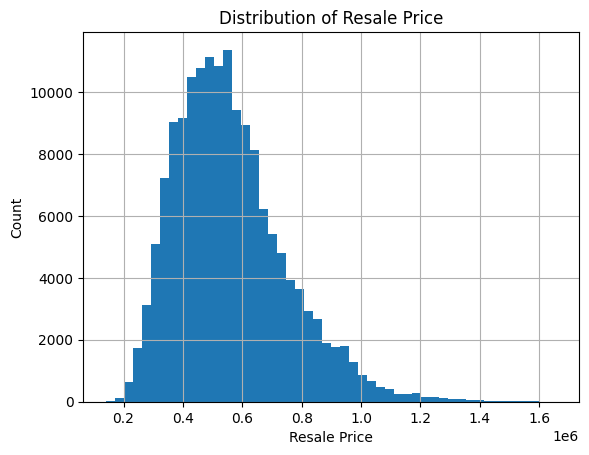

In [8]:
# Check distributions
df_model["resale_price"].hist(bins=50)
plt.title("Distribution of Resale Price")
plt.xlabel("Resale Price")
plt.ylabel("Count")
plt.show()

In [9]:
# Create stratification variable
# Create year from month
df_model["year"] = pd.to_datetime(df_model["month"]).dt.year.astype(str)

# Create combined stratification variable
df_model["strata"] = (
    df_model["town"].astype(str) + "_" +
    df_model["flat_type"].astype(str) + "_" +
    df_model["year"]
)

# Remove rare strata that would break stratified splitting
strata_counts = df_model["strata"].value_counts()
valid_strata = strata_counts[strata_counts >= 2].index
df_model = df_model[df_model["strata"].isin(valid_strata)].copy()

print("Rows after filtering rare strata:", df_model.shape[0])
print("Number of strata groups:", df_model["strata"].nunique())

Rows after filtering rare strata: 157602
Number of strata groups: 762


In [10]:
# Train-test split with stratification
X = df_model[features].copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_model["strata"]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (126081, 14)
Test shape: (31521, 14)


In [11]:
# Confirm train/test balance
train_dist = X_train["flat_type"].value_counts(normalize=True).sort_index()
test_dist = X_test["flat_type"].value_counts(normalize=True).sort_index()

balance_check = pd.concat([train_dist, test_dist], axis=1)
balance_check.columns = ["train_prop", "test_prop"]
balance_check

,train_prop,test_prop
flat_type,,
1 ROOM,0.000325,0.000317
2 ROOM,0.022676,0.022683
3 ROOM,0.236150,0.236192
4 ROOM,0.427796,0.427873
5 ROOM,0.244446,0.244282
EXECUTIVE,0.068297,0.068399
MULTI-GENERATION,0.000309,0.000254


In [12]:
# Train validation split from training data
train_idx, val_idx = train_test_split(
    X_train.index,
    test_size=0.2,
    random_state=42,
    stratify=X_train["flat_type"]
)

X_train_sub = X_train.loc[train_idx]
y_train_sub = y_train.loc[train_idx]

X_val = X_train.loc[val_idx]
y_val = y_train.loc[val_idx]

print(X_train_sub.shape, X_val.shape, X_test.shape)

(100864, 14) (25217, 14) (31521, 14)


In [13]:
# Train CatBoost model
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=100
)

model.fit(
    X_train_sub,
    y_train_sub,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 181325.6084877	test: 181172.9653118	best: 181172.9653118 (0)	total: 232ms	remaining: 7m 44s
100:	learn: 56730.4202339	test: 54275.6010900	best: 54275.6010900 (100)	total: 5.52s	remaining: 1m 43s
200:	learn: 49272.6202668	test: 46462.6850362	best: 46462.6850362 (200)	total: 11.5s	remaining: 1m 42s
300:	learn: 45470.3311205	test: 42667.4027467	best: 42667.4027467 (300)	total: 17.2s	remaining: 1m 36s
400:	learn: 43048.3309722	test: 40380.5621382	best: 40380.5621382 (400)	total: 23.2s	remaining: 1m 32s
500:	learn: 41160.5163709	test: 38680.1776050	best: 38680.1776050 (500)	total: 33.9s	remaining: 1m 41s
600:	learn: 39796.6479467	test: 37536.5984694	best: 37536.5984694 (600)	total: 46.1s	remaining: 1m 47s
700:	learn: 38667.4347349	test: 36670.5365390	best: 36670.5365390 (700)	total: 58.8s	remaining: 1m 48s
800:	learn: 37758.7092259	test: 35984.9582761	best: 35984.9582761 (800)	total: 1m 11s	remaining: 1m 47s
900:	learn: 36890.1049666	test: 35299.6570759	best: 35299.6570759 (900)	t

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=2000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [14]:
# Predict on validation and test sets
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

In [15]:
# Evaluate standard metrics
def regression_metrics(y_true, y_pred, label="dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{label} RMSE: {rmse:,.2f}")
    print(f"{label} MAE : {mae:,.2f}")
    print(f"{label} R^2 : {r2:.4f}")
    
regression_metrics(y_val, val_preds, label="Validation")
print()
regression_metrics(y_test, test_preds, label="Test")

Validation RMSE: 32,203.66
Validation MAE : 23,062.33
Validation R^2 : 0.9705

Test RMSE: 33,008.15
Test MAE : 23,485.54
Test R^2 : 0.9691
